In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Load dataset
data = pd.read_csv("//content/drive/MyDrive/Phishing_Email/datasets/Malicious_URLs.csv")

# Basic check
print(data.head())
print(data.info())

                                                URLs Class
0                    freebase.com/view/en/bob_sirois  good
1                     en.wikipedia.org/wiki/Joie_Lee  good
2           pipl.com/directory/people/Rejean/Beaudin  good
3  flickr.com/photos/teneyck/sets/72157610336209297/  good
4  ussoccer.com/News/Federation-Services/2009/06/...  good
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51329 entries, 0 to 51328
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   URLs    51329 non-null  object
 1   Class   51329 non-null  object
dtypes: object(2)
memory usage: 802.1+ KB
None


In [ ]:
data.columns = ['url', 'label']

In [ ]:
# Check nulls
print(data.isnull().sum())

# Drop missing
data.dropna(inplace=True)

url      0
label    0
dtype: int64


In [ ]:
#remove duplicates
data.drop_duplicates(inplace=True)

In [ ]:
import re

def clean_url(url):
    url = url.lower()                      # lowercase
    url = url.strip()                      # remove spaces
    url = re.sub(r'https?://', '', url)    # remove http/https
    url = re.sub(r'www\.', '', url)        # remove www
    return url

data['clean_url'] = data['url'].apply(clean_url)

In [ ]:
# good = 0, bad = 1 (important for ML)
data['label'] = data['label'].map({'good': 0, 'bad': 1})

In [ ]:
data['url_length'] = data['clean_url'].apply(len)

In [ ]:
data['dot_count'] = data['clean_url'].apply(lambda x: x.count('.'))

In [ ]:
data['slash_count'] = data['clean_url'].apply(lambda x: x.count('/'))

In [ ]:
data['digit_count'] = data['clean_url'].apply(lambda x: sum(c.isdigit() for c in x))

In [ ]:
def count_special_chars(url):
    return len(re.findall(r'[^a-zA-Z0-9]', url))

data['special_char_count'] = data['clean_url'].apply(count_special_chars)

In [ ]:
# Feature: Check for IP address in URL
def has_ip(url):
    return 1 if re.search(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', url) else 0

data['has_ip'] = data['clean_url'].apply(has_ip)

import re

In [ ]:
suspicious_words = ['login', 'secure', 'account', 'bank', 'verify', 'update', 'free']

def has_suspicious(url):
    return int(any(word in url for word in suspicious_words))

data['has_suspicious_words'] = data['clean_url'].apply(has_suspicious)

In [ ]:
data['has_https'] = data['url'].apply(lambda x: 1 if 'https' in x else 0)

In [ ]:
data['hyphen_count'] = data['clean_url'].apply(lambda x: x.count('-'))

In [ ]:
def subdomain_count(url):
    return url.count('.') - 1

data['subdomain_count'] = data['clean_url'].apply(subdomain_count)

In [ ]:
print(data.head())
print(data.shape)

                                                 url  label  \
0                    freebase.com/view/en/bob_sirois      0   
1                     en.wikipedia.org/wiki/Joie_Lee      0   
2           pipl.com/directory/people/Rejean/Beaudin      0   
3  flickr.com/photos/teneyck/sets/72157610336209297/      0   
4  ussoccer.com/News/Federation-Services/2009/06/...      0   

                                           clean_url  url_length  dot_count  \
0                    freebase.com/view/en/bob_sirois          31          1   
1                     en.wikipedia.org/wiki/joie_lee          30          2   
2           pipl.com/directory/people/rejean/beaudin          40          1   
3  flickr.com/photos/teneyck/sets/72157610336209297/          49          1   
4  ussoccer.com/news/federation-services/2009/06/...         151          2   

   slash_count  digit_count  special_char_count  has_ip  has_suspicious_words  \
0            3            0                   5       0          

In [ ]:
import os

output_drive_path = '/content/drive/MyDrive/Phishing_Project/cleaned_data'

if not os.path.exists(output_drive_path):
    os.makedirs(output_drive_path)

data.to_csv(
    os.path.join(output_drive_path, 'cleaned_url_dataset.csv'),
    index=False
)

In [ ]:
from urllib.parse import urlparse

def get_domain(url):
    try:
        return urlparse("http://" + url).netloc
    except:
        return ""

data['domain'] = data['clean_url'].apply(get_domain)

In [ ]:
data['domain_length'] = data['domain'].apply(len)

In [ ]:
shorteners = ['bit.ly', 'tinyurl.com', 'goo.gl', 't.co']

def is_shortened(url):
    return int(any(short in url for short in shorteners))

data['is_shortened'] = data['clean_url'].apply(is_shortened)

In [ ]:
data['at_symbol_count'] = data['clean_url'].apply(lambda x: x.count('@'))

In [ ]:
data['equal_count'] = data['clean_url'].apply(lambda x: x.count('='))

In [ ]:
data['digit_ratio'] = data['digit_count'] / data['url_length']
data['special_char_ratio'] = data['special_char_count'] / data['url_length']

In [ ]:
import math
from collections import Counter

def entropy(url):
    prob = [float(url.count(c)) / len(url) for c in dict.fromkeys(list(url))]
    return -sum([p * math.log2(p) for p in prob])

data['url_entropy'] = data['clean_url'].apply(entropy)

In [ ]:
data['label'].value_counts()

,count
label,
0,42057
1,9083


In [ ]:
final_data = data.drop(columns=['url', 'clean_url'])

In [ ]:
data.head()

,url,label,clean_url,url_length,dot_count,slash_count,digit_count,special_char_count,has_ip,has_suspicious_words,...,hyphen_count,subdomain_count,domain,domain_length,is_shortened,at_symbol_count,equal_count,digit_ratio,special_char_ratio,url_entropy
0,freebase.com/view/en/bob_sirois,0,freebase.com/view/en/bob_sirois,31,1,3,0,5,0,1,...,0,0,freebase.com,12,0,0,0,0.000000,0.161290,3.748258
1,en.wikipedia.org/wiki/Joie_Lee,0,en.wikipedia.org/wiki/joie_lee,30,2,2,0,5,0,0,...,0,1,en.wikipedia.org,16,0,0,0,0.000000,0.166667,3.669577
2,pipl.com/directory/people/Rejean/Beaudin,0,pipl.com/directory/people/rejean/beaudin,40,1,4,0,5,0,0,...,0,0,pipl.com,8,0,0,0,0.000000,0.125000,3.927567
3,flickr.com/photos/teneyck/sets/72157610336209297/,0,flickr.com/photos/teneyck/sets/72157610336209297/,49,1,5,17,6,0,0,...,0,0,flickr.com,10,0,0,0,0.346939,0.122449,4.453611
4,ussoccer.com/News/Federation-Services/2009/06/...,0,ussoccer.com/news/federation-services/2009/06/...,151,2,5,6,25,0,0,...,18,1,ussoccer.com,12,0,0,0,0.039735,0.165563,4.381148


In [ ]:
import os

# Define the full path to the directory
output_dir_drive = '/content/drive/MyDrive/Phishing_Project/final_dataset'

# Create the directory if it does not exist
if not os.path.exists(output_dir_drive):
    os.makedirs(output_dir_drive)

# Saving the final processed dataset with all engineered features to Google Drive
data.to_csv(
    os.path.join(output_dir_drive, 'final_preprocessed_dataset_niketan.csv'),
    index=False
)

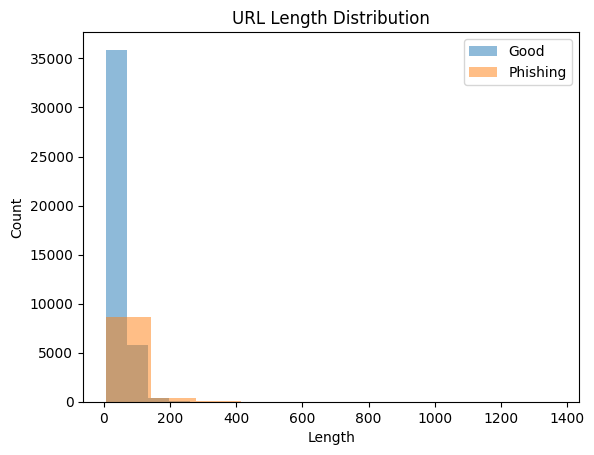

In [ ]:
import matplotlib.pyplot as plt

plt.hist(data[data['label']==0]['url_length'], alpha=0.5, label='Good')
plt.hist(data[data['label']==1]['url_length'], alpha=0.5, label='Phishing')

plt.legend()
plt.title("URL Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

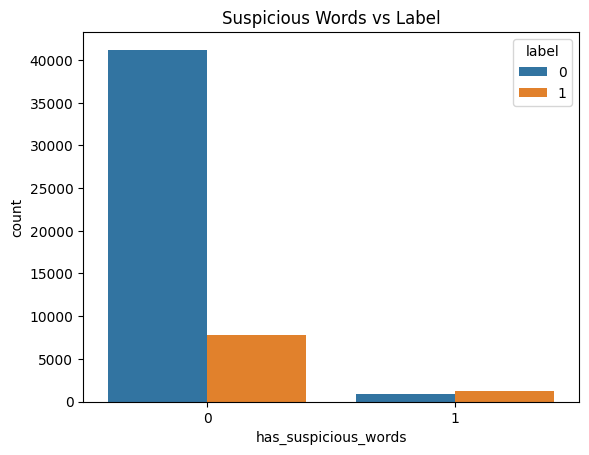

In [ ]:
import seaborn as sns

sns.countplot(x='has_suspicious_words', hue='label', data=data)
plt.title("Suspicious Words vs Label")
plt.show()

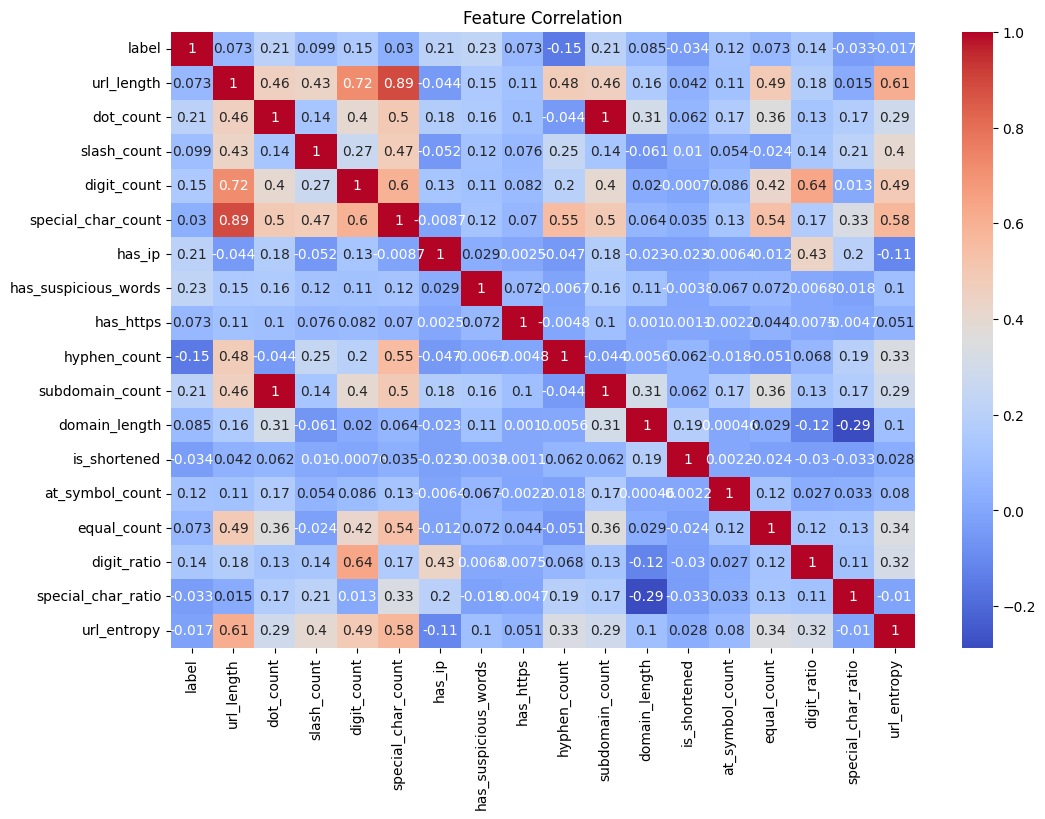

In [ ]:
plt.figure(figsize=(12,8))

numeric_data = final_data.select_dtypes(include=['number'])

sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation")
plt.show()

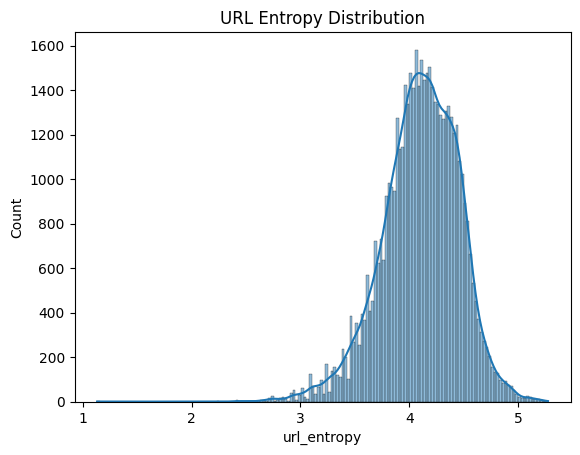

In [ ]:
sns.histplot(data['url_entropy'], kde=True)
plt.title("URL Entropy Distribution")
plt.show()

In [ ]:
# Loading the dataset from Google Drive into a pandas DataFrame
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Phishing_Email/final_dataset/final_preprocessed_dataset_niketan.csv')

In [ ]:
df.head()

,url,label,clean_url,url_length,dot_count,slash_count,digit_count,special_char_count,has_ip,has_suspicious_words,...,hyphen_count,subdomain_count,domain,domain_length,is_shortened,at_symbol_count,equal_count,digit_ratio,special_char_ratio,url_entropy
0,freebase.com/view/en/bob_sirois,0,freebase.com/view/en/bob_sirois,31,1,3,0,5,0,1,...,0,0,freebase.com,12,0,0,0,0.000000,0.161290,3.748258
1,en.wikipedia.org/wiki/Joie_Lee,0,en.wikipedia.org/wiki/joie_lee,30,2,2,0,5,0,0,...,0,1,en.wikipedia.org,16,0,0,0,0.000000,0.166667,3.669577
2,pipl.com/directory/people/Rejean/Beaudin,0,pipl.com/directory/people/rejean/beaudin,40,1,4,0,5,0,0,...,0,0,pipl.com,8,0,0,0,0.000000,0.125000,3.927567
3,flickr.com/photos/teneyck/sets/72157610336209297/,0,flickr.com/photos/teneyck/sets/72157610336209297/,49,1,5,17,6,0,0,...,0,0,flickr.com,10,0,0,0,0.346939,0.122449,4.453611
4,ussoccer.com/News/Federation-Services/2009/06/...,0,ussoccer.com/news/federation-services/2009/06/...,151,2,5,6,25,0,0,...,18,1,ussoccer.com,12,0,0,0,0.039735,0.165563,4.381148


In [ ]:
import pandas as pd
import os

file_path = '/content/drive/MyDrive/Phishing_Project/final_dataset/final_preprocessed_dataset_niketan.csv'

# Assuming df was successfully loaded in cell oBVAzH-1XIIj
data = df

print(data.head())
print(data.shape)

                                                 url  label  \
0                    freebase.com/view/en/bob_sirois      0   
1                     en.wikipedia.org/wiki/Joie_Lee      0   
2           pipl.com/directory/people/Rejean/Beaudin      0   
3  flickr.com/photos/teneyck/sets/72157610336209297/      0   
4  ussoccer.com/News/Federation-Services/2009/06/...      0   

                                           clean_url  url_length  dot_count  \
0                    freebase.com/view/en/bob_sirois          31          1   
1                     en.wikipedia.org/wiki/joie_lee          30          2   
2           pipl.com/directory/people/rejean/beaudin          40          1   
3  flickr.com/photos/teneyck/sets/72157610336209297/          49          1   
4  ussoccer.com/news/federation-services/2009/06/...         151          2   

   slash_count  digit_count  special_char_count  has_ip  has_suspicious_words  \
0            3            0                   5       0          

In [ ]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))

label
0    42057
1     9083
Name: count, dtype: int64
label
0    0.82239
1    0.17761
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# STEP 0 — INSTALL DEPENDENCIES
# ============================================================

!pip install xgboost tensorflow scikit-learn pandas numpy matplotlib seaborn joblib -q

In [ ]:
# ============================================================
# STEP 1 — IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc,
    roc_auc_score, f1_score
)
from sklearn.feature_extraction.text import TfidfVectorizer

from xgboost import XGBClassifier

import tensorflow as tf

# ← Explicit aliases to avoid xgboost overwriting these
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout, BatchNormalization, Concatenate
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (
    EarlyStopping     as KerasEarlyStopping,   # ← aliased
    ReduceLROnPlateau as KerasReduceLR,         # ← aliased
    ModelCheckpoint   as KerasCheckpoint        # ← aliased
)

In [ ]:
# ============================================================
# STEP 2 — LOAD DATA
# ============================================================

df = pd.read_csv('/content/drive/MyDrive/Phishing_Project/final_dataset/final_preprocessed_dataset_niketan.csv')

# Check label balance — IMPORTANT
print("Label Distribution:")
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))

y = df["label"]

Label Distribution:
label
0    42057
1     9083
Name: count, dtype: int64
label
0    0.82239
1    0.17761
Name: proportion, dtype: float64


In [ ]:
#============================================================
# STEP 3 — FEATURE ENGINEERING (EXPANDED)
# ============================================================

import re
import math
from urllib.parse import urlparse

def get_entropy(url):
    """Shannon entropy of URL string"""
    if not url or len(url) == 0:
        return 0
    prob = [url.count(c) / len(url) for c in set(url)]
    return -sum(p * math.log2(p) for p in prob if p > 0)

def extract_features(df):
    df = df.copy()
    df['clean_url'] = df['url'].fillna('').str.lower().str.strip()

    # --- Original features ---
    df['url_length']         = df['clean_url'].apply(len)
    df['dot_count']          = df['clean_url'].apply(lambda x: x.count('.'))
    df['slash_count']        = df['clean_url'].apply(lambda x: x.count('/'))
    df['digit_count']        = df['clean_url'].apply(lambda x: sum(c.isdigit() for c in x))
    df['special_char_count'] = df['clean_url'].apply(lambda x: sum(not c.isalnum() for c in x))
    df['has_ip']             = df['clean_url'].apply(
        lambda x: int(bool(re.search(r'\d+\.\d+\.\d+\.\d+', x)))
    )
    df['has_suspicious_words'] = df['clean_url'].apply(
        lambda x: int(any(w in x for w in [
            'login', 'verify', 'update', 'secure', 'account',
            'banking', 'confirm', 'password', 'signin', 'free'
        ]))
    )
    df['hyphen_count']    = df['clean_url'].apply(lambda x: x.count('-'))

    # Modified subdomain_count with error handling
    def get_subdomain_count_safe(url_string):
        try:
            netloc = urlparse('http://' + url_string).netloc
            if not netloc: # If netloc is empty after parsing, assume 0 subdomains
                return 0
            # A simple split by dot will work for most cases, subtract 2 for top-level domain and domain itself
            return len(netloc.split('.')) - 2
        except ValueError:
            return 0 # Handle invalid IPv6 URL or other urlparse errors

    df['subdomain_count'] = df['clean_url'].apply(get_subdomain_count_safe)

    # Modified domain_length with error handling
    def get_domain_length_safe(url_string):
        try:
            return len(urlparse('http://' + url_string).netloc)
        except ValueError:
            return 0 # Handle invalid IPv6 URL or other urlparse errors

    df['domain_length']   = df['clean_url'].apply(get_domain_length_safe)

    df['is_shortened']    = df['clean_url'].apply(
        lambda x: int(any(s in x for s in ['bit.ly', 'tinyurl', 'goo.gl', 't.co', 'ow.ly']))
    )
    df['at_symbol_count'] = df['clean_url'].apply(lambda x: x.count('@'))
    df['equal_count']     = df['clean_url'].apply(lambda x: x.count('='))
    df['digit_ratio']     = df['digit_count'] / (df['url_length'] + 1)
    df['special_char_ratio'] = df['special_char_count'] / (df['url_length'] + 1)
    df['url_entropy']     = df['clean_url'].apply(get_entropy)

    # --- NEW features (improves class 1 detection) ---
    df['has_https']       = df['clean_url'].apply(lambda x: int(x.startswith('https')))
    df['url_depth']       = df['clean_url'].apply(
        lambda x: len([p for p in x.split('/') if p])
    )
    df['suspicious_tld']  = df['clean_url'].apply(
        lambda x: int(any(x.endswith(t) for t in [
            '.tk', '.ml', '.ga', '.cf', '.gq', '.xyz', '.top', '.pw', '.click'
        ]))
    )
    df['query_param_count'] = df['clean_url'].apply(
        lambda x: x.count('&') + (1 if '?' in x else 0)
    )
    df['double_slash_count'] = df['clean_url'].apply(lambda x: x.count('//'))
    df['percent_count']      = df['clean_url'].apply(lambda x: x.count('%'))
    df['tilde_count']        = df['clean_url'].apply(lambda x: x.count('~'))
    df['www_count']          = df['clean_url'].apply(lambda x: x.count('www'))
    df['has_port']           = df['clean_url'].apply(
        lambda x: int(bool(re.search(r':\d{2,5}', x)))
    )

    return df

df = extract_features(df)
print("Features created:", df.shape)


Features created: (51140, 29)


In [ ]:
# ============================================================
# STEP 4 — DEFINE FEATURE LIST (EXPANDED)
# ============================================================

url_features = [
    # Original
    "url_length", "dot_count", "slash_count", "digit_count",
    "special_char_count", "has_ip", "has_suspicious_words",
    "hyphen_count", "subdomain_count", "domain_length",
    "is_shortened", "at_symbol_count", "equal_count",
    "digit_ratio", "special_char_ratio", "url_entropy",
    # New
    "has_https", "url_depth", "suspicious_tld",
    "query_param_count", "double_slash_count", "percent_count",
    "tilde_count", "www_count", "has_port"
]

In [ ]:
# ============================================================
# STEP 5 — SAVE FEATURE FILES
# ============================================================

df.to_csv(
    "/content/drive/MyDrive/Phishing_Project/url_features/url_engineered_features.csv",
    index=False
)

domain_df = df[["domain_length", "subdomain_count", "is_shortened",
                "has_ip", "has_suspicious_words", "suspicious_tld"]]
domain_df.to_csv(
    "/content/drive/MyDrive/Phishing_Project/url_features/domain_features.csv",
    index=False
)

entropy_df = df[["clean_url", "url_entropy", "label"]]
entropy_df.to_csv(
    "/content/drive/MyDrive/Phishing_Project/url_features/url_entropy_scores.csv",
    index=False
)

In [ ]:
# ============================================================
# STEP 6 — URL EMBEDDINGS (TF-IDF CHARACTER LEVEL)
# ============================================================

df['clean_url'] = df['clean_url'].fillna('')

url_vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 5),
    max_features=5000
)

url_vectors = url_vectorizer.fit_transform(df['clean_url'])

np.save(
    "/content/drive/MyDrive/Phishing_Project/url_features/url_embeddings.npy",
    url_vectors.toarray()
)

joblib.dump(
    url_vectorizer,
    "/content/drive/MyDrive/Phishing_Project/url_features/url_vectorizer.pkl"
)

['/content/drive/MyDrive/Phishing_Project/url_features/url_vectorizer.pkl']

In [ ]:
# ============================================================
# STEP 7 — TRAIN/TEST SPLIT
# ============================================================

X = df[url_features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Class imbalance ratio for XGBoost
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
class_ratio = neg / pos
print(f"\nClass ratio (neg/pos): {class_ratio:.2f}")
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")



Class ratio (neg/pos): 4.63
Train size: 40912, Test size: 10228


In [ ]:
# ============================================================
# STEP 8 — SCALE FEATURES
# ============================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, "/content/drive/MyDrive/Phishing_Project/url_features/url_scaler.pkl")

['/content/drive/MyDrive/Phishing_Project/url_features/url_scaler.pkl']

In [ ]:
# ============================================================
# STEP 9 — EVALUATION HELPER FUNCTION
# ============================================================

def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{'='*50}")
    print(f"  Model: {name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  AUC-ROC  : {roc_auc_score(y_true, y_prob):.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=['Safe (0)', 'Phishing (1)']))

    # Confusion Matrix
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Safe', 'Phishing'],
                yticklabels=['Safe', 'Phishing'])
    axes[0].set_title(f'{name} — Confusion Matrix')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}', linewidth=2)
    axes[1].plot([0, 1], [0, 1], 'k--')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{name} — ROC Curve')
    axes[1].legend()

    plt.tight_layout()
    plt.show()



  Model: Logistic Regression
  Accuracy : 0.5248
  AUC-ROC  : 0.7892
              precision    recall  f1-score   support

    Safe (0)       0.96      0.44      0.61      8411
Phishing (1)       0.26      0.90      0.40      1817

    accuracy                           0.52     10228
   macro avg       0.61      0.67      0.50     10228
weighted avg       0.83      0.52      0.57     10228



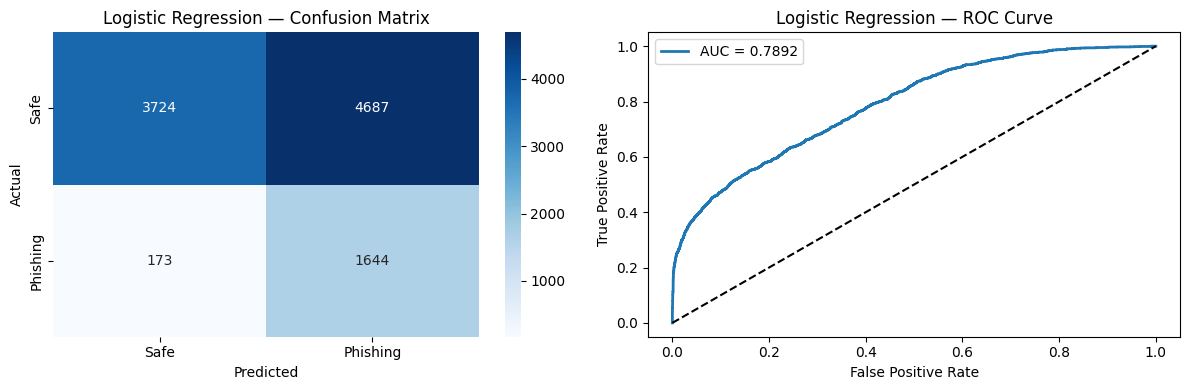

['/content/drive/MyDrive/Phishing_Project/models/url_classifier.pkl']

In [ ]:
# ============================================================
# STEP 10 — LOGISTIC REGRESSION
# ============================================================

url_lr = LogisticRegression(
    max_iter=10000,
    class_weight='balanced',
    C=0.5,
    random_state=42
)

url_lr.fit(X_train_scaled, y_train)

lr_prob = url_lr.predict_proba(X_test_scaled)[:, 1]
lr_pred = (lr_prob >= 0.35).astype(int)   # tuned threshold

evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)

joblib.dump(
    url_lr,
    "/content/drive/MyDrive/Phishing_Project/models/url_classifier.pkl"
)


  Model: Random Forest
  Accuracy : 0.8808
  AUC-ROC  : 0.9460
              precision    recall  f1-score   support

    Safe (0)       0.97      0.89      0.92      8411
Phishing (1)       0.62      0.86      0.72      1817

    accuracy                           0.88     10228
   macro avg       0.79      0.87      0.82     10228
weighted avg       0.90      0.88      0.89     10228



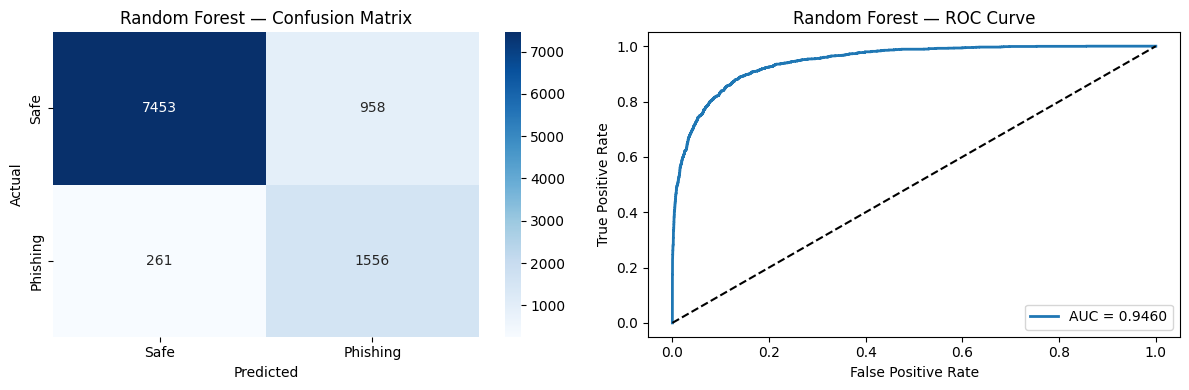

['/content/drive/MyDrive/Phishing_Project/models/url_rf_model.pkl']

In [ ]:
# ============================================================
# STEP 11 — RANDOM FOREST (TUNED)
# ============================================================

url_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    min_samples_leaf=2,
    class_weight='balanced',   # KEY FIX
    random_state=42,
    n_jobs=-1
)

url_rf.fit(X_train, y_train)

rf_prob = url_rf.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= 0.35).astype(int)   # tuned threshold

evaluate_model("Random Forest", y_test, rf_pred, rf_prob)

joblib.dump(
    url_rf,
    "/content/drive/MyDrive/Phishing_Project/models/url_rf_model.pkl"
)

[0]	validation_0-logloss:0.67765
[50]	validation_0-logloss:0.41718
[100]	validation_0-logloss:0.35373
[150]	validation_0-logloss:0.32370
[200]	validation_0-logloss:0.30687
[250]	validation_0-logloss:0.29506
[299]	validation_0-logloss:0.28685

  Model: XGBoost
  Accuracy : 0.8177
  AUC-ROC  : 0.9453
              precision    recall  f1-score   support

    Safe (0)       0.98      0.79      0.88      8411
Phishing (1)       0.49      0.93      0.64      1817

    accuracy                           0.82     10228
   macro avg       0.74      0.86      0.76     10228
weighted avg       0.89      0.82      0.84     10228



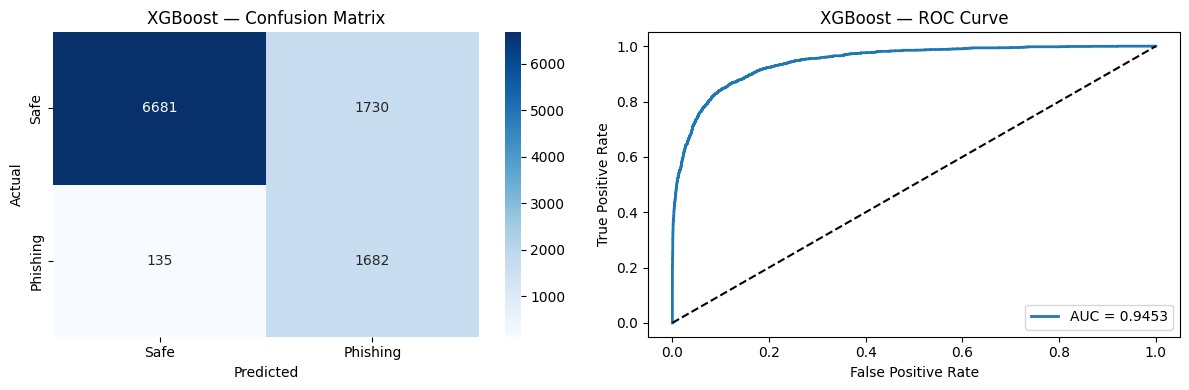

['/content/drive/MyDrive/Phishing_Project/models/url_xgb_model.pkl']

In [ ]:
# ============================================================
# STEP 12 — XGBOOST (IMPROVED)
# ============================================================

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=class_ratio,
    eval_metric='logloss',
    early_stopping_rounds=20,   # ← MOVED HERE (into constructor)
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=50
    # ← early_stopping_rounds removed from here
)

xgb_prob = xgb.predict_proba(X_test_scaled)[:, 1]
xgb_pred = (xgb_prob >= 0.35).astype(int)

evaluate_model("XGBoost", y_test, xgb_pred, xgb_prob)

joblib.dump(
    xgb,
    "/content/drive/MyDrive/Phishing_Project/models/url_xgb_model.pkl"
)


Top 10 Most Important Features:
             Feature  Importance
has_suspicious_words    0.178119
           www_count    0.102305
        hyphen_count    0.073477
              has_ip    0.063934
           dot_count    0.055384
         digit_count    0.050922
         slash_count    0.048556
     at_symbol_count    0.046496
           url_depth    0.038874
            has_port    0.035642


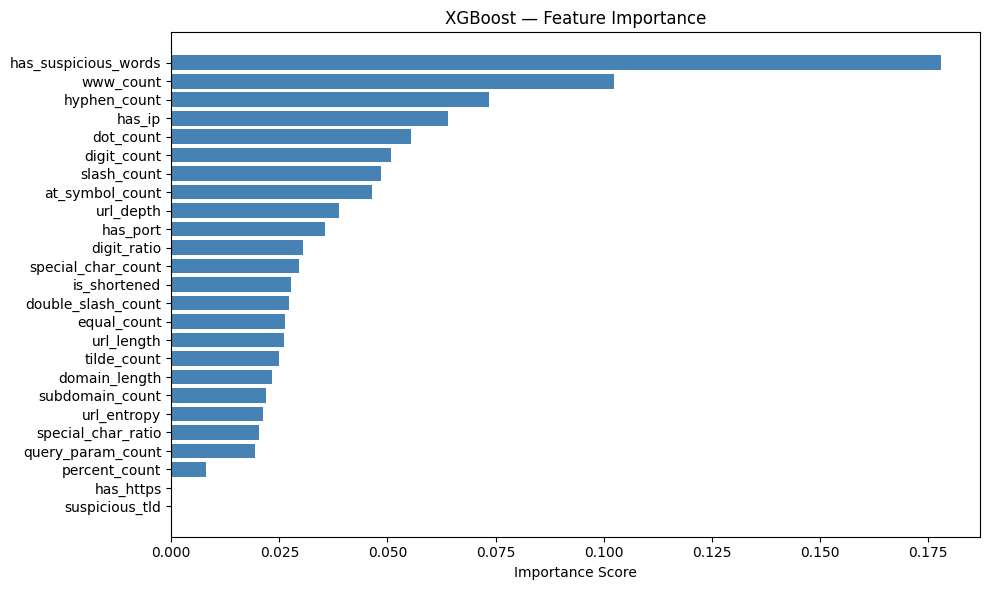

In [ ]:
# ============================================================
# STEP 13 — XGBOOST FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({
    'Feature': url_features,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('XGBoost — Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# STEP 14 — CNN (IMPROVED MULTI-FILTER)
# ============================================================

max_words = 10000
max_len   = 200

tokenizer = Tokenizer(num_words=max_words, char_level=True)
tokenizer.fit_on_texts(df['clean_url'])

sequences = tokenizer.texts_to_sequences(df['clean_url'])
X_seq     = pad_sequences(sequences, maxlen=max_len)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Build improved CNN
def build_cnn(max_words=10000, max_len=200):
    inp = Input(shape=(max_len,))
    x   = Embedding(input_dim=max_words, output_dim=128)(inp)

    conv3 = GlobalMaxPooling1D()(Conv1D(128, 3, activation='relu', padding='same')(x))
    conv5 = GlobalMaxPooling1D()(Conv1D(128, 5, activation='relu', padding='same')(x))
    conv7 = GlobalMaxPooling1D()(Conv1D(128, 7, activation='relu', padding='same')(x))

    merged = Concatenate()([conv3, conv5, conv7])

    out = Dense(256, activation='relu')(merged)
    out = BatchNormalization()(out)
    out = Dropout(0.4)(out)
    out = Dense(64, activation='relu')(out)
    out = Dropout(0.2)(out)
    out = Dense(1, activation='sigmoid')(out)

    model = Model(inp, out)
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn()
cnn_model.summary()

# Class weights for CNN
class_weight_cnn = {0: 1, 1: int(class_ratio)}

# ← Using aliased Keras callbacks — fixes the TypeError
callbacks = [
    KerasEarlyStopping(
        monitor='val_loss', patience=4,
        restore_best_weights=True, verbose=1
    ),
    KerasReduceLR(
        monitor='val_loss', factor=0.5,
        patience=2, verbose=1
    ),
    KerasCheckpoint(
        "/content/drive/MyDrive/Phishing_Project/models/best_cnn.h5",
        monitor='val_loss', save_best_only=True, verbose=1
    )
]

history = cnn_model.fit(
    X_train_seq, y_train_seq,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=callbacks,
    class_weight=class_weight_cnn
)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('CNN — Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('CNN — Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate CNN
cnn_prob = cnn_model.predict(X_test_seq).flatten()
cnn_pred = (cnn_prob >= 0.35).astype(int)

evaluate_model("CNN", y_test_seq, cnn_pred, cnn_prob)

cnn_model.save("/content/drive/MyDrive/Phishing_Project/models/url_cnn_model/")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 200, 128)  │  1,280,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 200, 128)  │     49,280 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 200, 128)  │     82,048 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 200, 128)  │    114,816 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_3[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_4[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_5[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     98,560 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │     16,448 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,642,241 (6.26 MB)

 Trainable params: 1,641,729 (6.26 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8629 - loss: 0.5037
Epoch 1: val_loss improved from None to 0.25439, saving model to /content/drive/MyDrive/Phishing_Project/models/best_cnn.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Phishing_Project/models/best_cnn.h5
288/288 ━━━━━━━━━━━━━━━━━━━━ 376s 1s/step - accuracy: 0.9059 - loss: 0.3740 - val_accuracy: 0.8761 - val_loss: 0.2544 - learning_rate: 0.0010
Epoch 2/20
  8/288 ━━━━━━━━━━━━━━━━━━━━ 5:00 1s/step - accuracy: 0.9545 - loss: 0.1762

In [ ]:
#============================================================
# STEP 15 — ENSEMBLE (STACK ALL MODELS)
# ============================================================

# Align CNN probabilities with classical model test set
# (Both use same random_state=42 split so indices match)
meta_X = np.column_stack([lr_prob, rf_prob, xgb_prob, cnn_prob])

meta_model = LogisticRegression(random_state=42)
meta_model.fit(meta_X, y_test)

meta_prob = meta_model.predict_proba(meta_X)[:, 1]
meta_pred = (meta_prob >= 0.35).astype(int)

evaluate_model("Ensemble (All Models)", y_test, meta_pred, meta_prob)

joblib.dump(
    meta_model,
    "/content/drive/MyDrive/Phishing_Project/models/url_ensemble_model.pkl"
)



<Dense name=dense, built=False>

In [ ]:
# ============================================================
# STEP 16 — URL RISK SCORE & FINAL PREDICTIONS
# ============================================================

X_all     = df[url_features].copy()
X_all_sc  = scaler.transform(X_all)

# Use XGBoost as primary scorer (best single model)
df['url_score']        = xgb.predict_proba(X_all_sc)[:, 1] * 100
df['final_prediction'] = (df['url_score'] >= 35).astype(int)

# Risk label
def risk_label(score):
    if score >= 75:  return 'HIGH RISK'
    if score >= 40:  return 'MEDIUM RISK'
    return 'SAFE'

df['risk_level'] = df['url_score'].apply(risk_label)

print("\nRisk Level Distribution:")
print(df['risk_level'].value_counts())
print("\nSample Predictions:")
print(df[['clean_url', 'url_score', 'risk_level', 'label']].head(10).to_string(index=False))


CNN Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

1023/1023 ━━━━━━━━━━━━━━━━━━━━ 32s 29ms/step - accuracy: 0.8204 - loss: 0.4814 - val_accuracy: 0.8251 - val_loss: 0.4636


In [ ]:
# ============================================================
# STEP 17 — MODEL COMPARISON SUMMARY
# ============================================================

models = {
    'Logistic Regression': (lr_pred, lr_prob),
    'Random Forest':        (rf_pred, rf_prob),
    'XGBoost':              (xgb_pred, xgb_prob),
    'CNN':                  (cnn_pred, cnn_prob),
    'Ensemble':             (meta_pred, meta_prob),
}

print("\n" + "="*65)
print(f"{'Model':<25} {'Accuracy':>10} {'AUC':>8} {'F1-Phish':>10}")
print("="*65)

for name, (pred, prob) in models.items():
    acc   = accuracy_score(y_test, pred)
    auc_s = roc_auc_score(y_test, prob)
    from sklearn.metrics import f1_score
    f1    = f1_score(y_test, pred)
    print(f"{name:<25} {acc:>10.4f} {auc_s:>8.4f} {f1:>10.4f}")

print("="*65)


320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8224 - loss: 0.4685
Test Loss: 0.4685
Test Accuracy: 0.8224


In [ ]:
# ============================================================
# STEP 18 — SAVE FINAL DATASET
# ============================================================

import os
os.makedirs("/content/drive/MyDrive/Phishing_Project/final_dataset", exist_ok=True)

df.to_csv(
    "/content/drive/MyDrive/Phishing_Project/final_dataset/url_final_features.csv",
    index=False
)

print("\n✅ All done! Files saved:")
print("  models/url_classifier.pkl")
print("  models/url_rf_model.pkl")
print("  models/url_xgb_model.pkl")
print("  models/url_cnn_model/")
print("  models/url_ensemble_model.pkl")
print("  final_dataset/url_final_features.csv")

